# AutoGluon — Predicción tasa USD/CUP (7 días)

**Objetivo:** predecir el valor `median` diario USD/CUP de eltoque.com
(vía API cubanomic) con AutoGluon TimeSeries, horizonte 7 días, CPU-only.
El `median` es el valor que publica el sitio como tipo de cambio del día.

**Criterio de éxito:** el ensemble AutoGluon supera el baseline naive en MAE y
MASE sobre los últimos 30 días.

**Decisiones congeladas:** solo USD (multi-moneda listo vía `CURRENCIES`),
target `median`, frecuencia diaria, fit completo una sola vez, re-exploración
manual (celda final).

In [2]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

# cwd = raíz del repo (src/, data/, models/ son relativos a ella)
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))

from src.data_loader import load_series

# Config única (cambiar aquí, no en celdas sueltas)
np.random.seed(42)
PREDICTION_LENGTH = 7
TEST_DAYS = 30
FREQ = "D"
PREDICTOR_PATH = "models/predictor"
RECIPE_PATH = "models/recipe.json"
OUTPUT_PATH = "output/predictions.json"
HISTORY_PATH = "output/history.jsonl" 

In [3]:
# Datos: fetch + fallback cache. Formato largo -> TimeSeriesDataFrame.
df_long = load_series(refresh=True)
tsdf = TimeSeriesDataFrame.from_data_frame(
    df_long, id_column="item_id", timestamp_column="timestamp"
)
print("shape:", tsdf.shape)
print(tsdf.head())
idx = tsdf.index.get_level_values("timestamp")
print("rango:", idx.min().date(), "→", idx.max().date()) 

shape: (728, 1)
                    target
item_id timestamp         
USD     2024-09-14   320.0
        2024-09-15   320.0
        2024-09-16   320.0
        2024-09-17   320.0
        2024-09-18   320.0
rango: 2024-09-14 → 2026-09-11


/tmp/ipykernel_157835/3278653257.py:2: UserWarning: fetch falló (CUBANOMIC_TOKEN no definida. Export en shell (~/.bashrc) o secret CUBANOMIC_TOKEN en GitHub Actions.); usando cache local
  df_long = load_series(refresh=True)


## EDA

Serie diaria ~2 años. Análisis: tendencia (medias móviles), estacionalidad
semanal (autocorrelación lag 7) y outliers (z-score > 3).

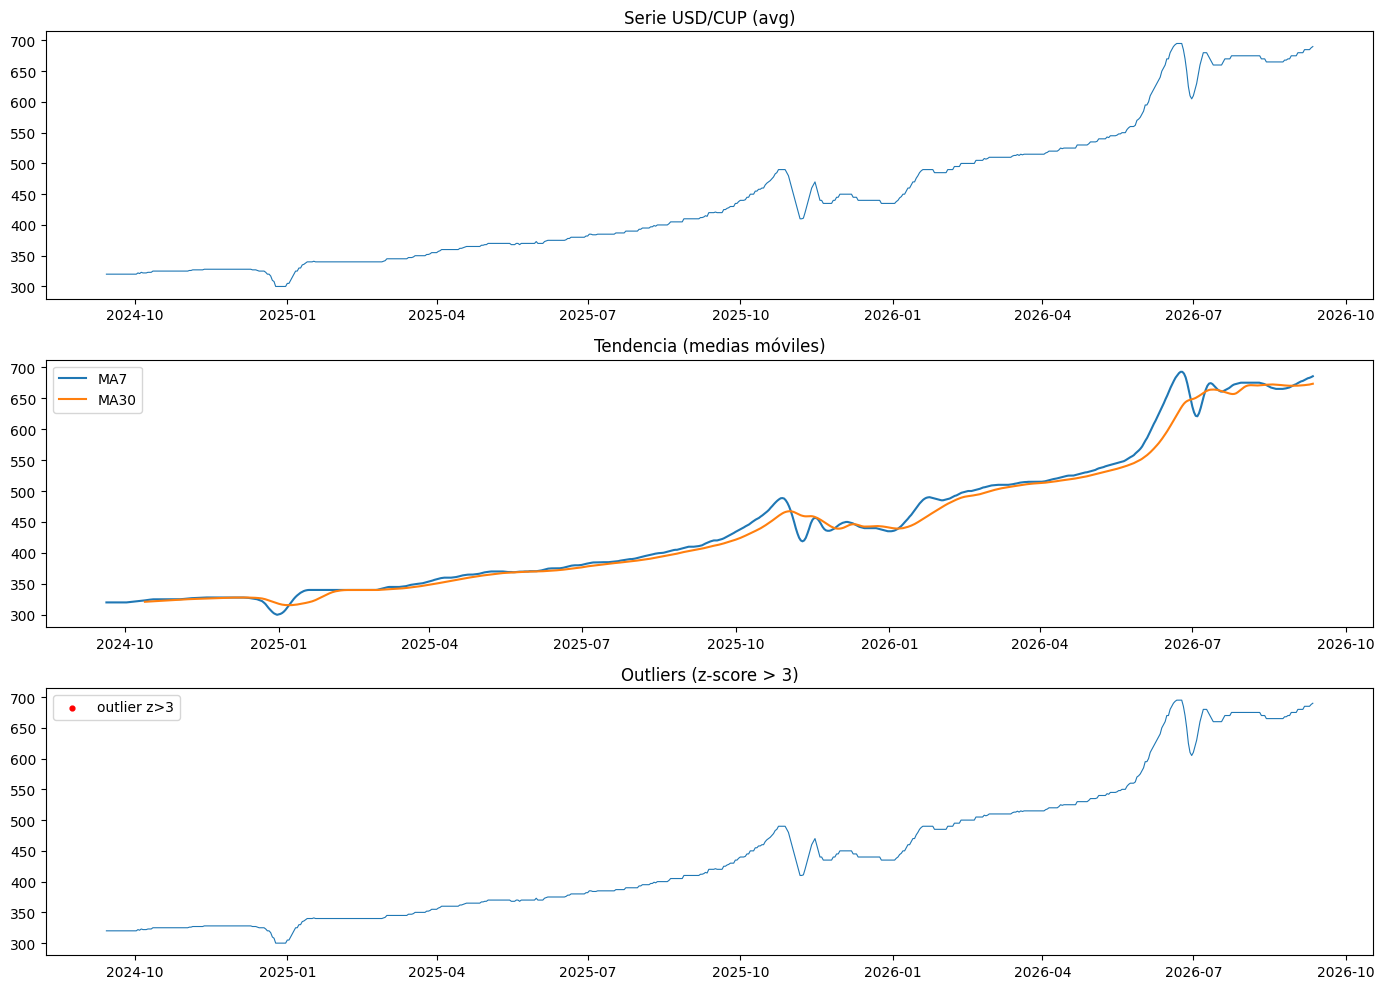

outliers z>3: 0
autocorr lag 1..14: [np.float64(1.0), np.float64(0.999), np.float64(0.998), np.float64(0.996), np.float64(0.994), np.float64(0.993), np.float64(0.991), np.float64(0.99), np.float64(0.989), np.float64(0.988), np.float64(0.987), np.float64(0.987), np.float64(0.986), np.float64(0.985)]


In [4]:
s = tsdf.loc["USD"]["target"]
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(s.index, s.values, lw=0.8)
axes[0].set_title("Serie USD/CUP (avg)")

axes[1].plot(s.index, s.rolling(7).mean(), label="MA7")
axes[1].plot(s.index, s.rolling(30).mean(), label="MA30")
axes[1].legend()
axes[1].set_title("Tendencia (medias móviles)")

z = (s - s.mean()) / s.std()
axes[2].plot(s.index, s.values, lw=0.8)
axes[2].scatter(s.index[np.abs(z) > 3], s[np.abs(z) > 3],
                color="red", s=12, label="outlier z>3")
axes[2].legend()
axes[2].set_title("Outliers (z-score > 3)")

plt.tight_layout()
plt.show()

acf = [s.autocorr(lag=k) for k in range(1, 15)]
print("outliers z>3:", int((np.abs(z) > 3).sum()))
print("autocorr lag 1..14:", [round(v, 3) for v in acf]) 

In [5]:
# Split: últimos TEST_DAYS = test, resto = train
train = tsdf.slice_by_timestep(None, -TEST_DAYS)
test = tsdf.slice_by_timestep(-TEST_DAYS, None)
print("train:", train.shape, "| test:", test.shape) 

train: (698, 1) | test: (30, 1)


In [ ]:
# Baselines: valores simples calculados sobre el conjunto de prueba.
s_train = train.loc["USD"]["target"]
s_test = test.loc["USD"]["target"]

naive_value = s_train.iloc[-1]
naive_pred = np.full(len(s_test), naive_value)

moving_average_value = s_train.tail(7).mean()
moving_average_pred = np.full(len(s_test), moving_average_value)


def mean_absolute_error(actual, predicted):
    errors = np.abs(actual - predicted)
    return float(np.mean(errors))


def root_mean_squared_error(actual, predicted):
    errors = actual - predicted
    squared_errors = errors ** 2
    return float(np.sqrt(np.mean(squared_errors)))


naive_mae = mean_absolute_error(s_test, naive_pred)
naive_rmse = root_mean_squared_error(s_test, naive_pred)
ma7_mae = mean_absolute_error(s_test, moving_average_pred)
ma7_rmse = root_mean_squared_error(s_test, moving_average_pred)

baselines = {
    "naive": {
        "MAE": naive_mae,
        "RMSE": naive_rmse,
    },
    "moving_avg_7": {
        "MAE": ma7_mae,
        "RMSE": ma7_rmse,
    },
}
pd.DataFrame(baselines).round(4)

,naive,moving_avg_7
MAE,7.2333,7.4714
RMSE,8.9573,8.3317
MASE,1.0690,1.1042


In [7]:
# fit() completo UNA sola vez (CPU, sin GPU).
# Excluir Chronos: muy lento en CPU.
predictor = TimeSeriesPredictor(
    prediction_length=PREDICTION_LENGTH,
    freq=FREQ,
    eval_metric="MASE",
    path=PREDICTOR_PATH,
)
predictor.fit(
    train,
    presets="medium_quality",
    time_limit=1800,              # 30 min; subir para exploración completa
    excluded_model_types=["Chronos"],
    verbosity=1,
) 

Loading weights: 100%|██████████| 92/92 [00:00<00:00, 7263.68it/s]


In [ ]:
# Leaderboard: score_val decide; score_test solo audita el hold-out
leaderboard = predictor.leaderboard(test)
leaderboard = leaderboard.sort_values("score_val", ascending=False)
print(leaderboard)

Loading weights: 100%|██████████| 92/92 [00:00<00:00, 8307.52it/s]


              model  score_test  score_val  pred_time_test  pred_time_val  \
0             Theta   -0.768913  -0.250798        1.639957       1.659276   
1  RecursiveTabular   -0.841026  -0.638916        0.050444       0.043316   
2             Toto2   -0.957768  -0.262313        0.616507       0.020859   
3  WeightedEnsemble   -0.965079  -0.173283        1.689979       1.961838   
4               ETS   -0.965079  -0.173283        1.689538       1.961443   
5     SeasonalNaive   -1.473016  -0.173283        1.184142       1.338040   
6          Chronos2   -1.752644  -0.221799        2.386595       0.220911   
7     DirectTabular   -4.168451  -2.736406        0.055706       0.045374   

   fit_time_marginal  fit_order  
0           0.011441          5  
1           0.338181          2  
2           0.855044          7  
3           0.261754          8  
4           0.008301          4  
5           0.010730          1  
6           6.159572          6  
7           0.339836          3  


In [ ]:
# Congelar receta. Solo esta celda decide el modelo de producción.
# score_val es la métrica de decisión; score_test queda como auditoría.
best_model = leaderboard["model"].iloc[0]

weights = {}
try:
    info = predictor.info()
    model_info = info.get("model_info", {})
    for model_name, model_data in model_info.items():
        if isinstance(model_data, dict) and "weight" in model_data:
            weights[model_name] = model_data["weight"]
except Exception:
    weights = {}

leaderboard_rows = leaderboard.reset_index().to_dict(orient="records")
for row in leaderboard_rows:
    score_val = row.get("score_val")
    if score_val is not None:
        row["score_val"] = abs(score_val)
    score_test = row.get("score_test")
    if score_test is not None:
        row["score_test"] = abs(score_test)

recipe = {
    "frozen_at": pd.Timestamp.utcnow().isoformat(),
    "eval_metric": "MASE",
    "prediction_length": PREDICTION_LENGTH,
    "freq": FREQ,
    "test_days": TEST_DAYS,
    "presets": "medium_quality",
    "excluded_model_types": ["Chronos"],
    "best_model": best_model,
    "ensemble_weights": weights,
    "leaderboard": leaderboard_rows,
    "baselines": baselines,
    "data_last_date": str(
        tsdf.index.get_level_values("timestamp").max().date()
    ),
}
Path(RECIPE_PATH).parent.mkdir(parents=True, exist_ok=True)
with open(RECIPE_PATH, "w") as f:
    json.dump(recipe, f, indent=2, default=str)
print("receta congelada en", RECIPE_PATH)
print("modelo congelado:", best_model)

receta congelada en models/recipe.json


                     mean         0.1         0.2         0.3         0.4  \
item_id timestamp                                                           
USD     2026-08-13  675.0  655.138838  661.956767  666.872973  671.073691   
        2026-08-14  675.0  655.138838  661.956767  666.872973  671.073691   
        2026-08-15  675.0  655.138838  661.956767  666.872973  671.073691   
        2026-08-16  675.0  655.138838  661.956767  666.872973  671.073691   
        2026-08-17  675.0  655.138838  661.956767  666.872973  671.073691   
        2026-08-18  670.0  650.138838  656.956767  661.872973  666.073691   
        2026-08-19  670.0  641.912075  651.554083  658.506649  664.447360   

                      0.5         0.6         0.7         0.8         0.9  
item_id timestamp                                                          
USD     2026-08-13  675.0  678.926309  683.127027  688.043233  694.861162  
        2026-08-14  675.0  678.926309  683.127027  688.043233  694.861162  
  

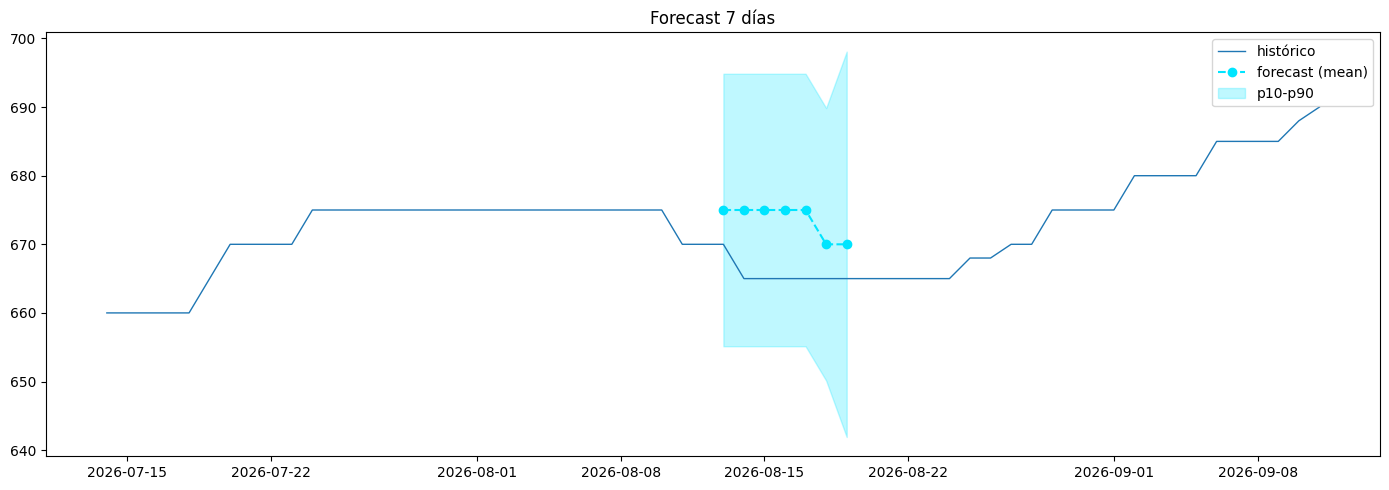

In [10]:
# Predicción demo 7 días + plot
forecast = predictor.predict(train)
print(forecast.head(PREDICTION_LENGTH))

f = forecast.loc["USD"]
s_hist = s_full[-60:]
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(s_hist.index, s_hist.values, label="histórico", lw=1)
ax.plot(f.index, f["mean"], "o--", color="#00e5ff", label="forecast (mean)")
if "0.1" in f.columns and "0.9" in f.columns:
    ax.fill_between(f.index, f["0.1"], f["0.9"], alpha=0.25, color="#00e5ff",
                    label="p10-p90")
ax.legend()
ax.set_title("Forecast 7 días")
plt.tight_layout()
plt.show() 

## Next steps

- **Producción**: `src/predict.py` (diario), `src/retrain.py` (semanal),
  `src/monitor.py` (mensual) — leen esta receta congelada.
- **CI**: `.github/workflows/` (daily_predict, weekly_retrain, monthly_check).
- **Frontend**: `frontend/index.html` consume `output/predictions.json`.


## Re-exploración manual (D3)

Ejecutar SOLO a voluntad: cada 3-6 meses, o si `src/monitor.py` detecta
degradación (MAE_7d > 1.5× baseline). NO automatizar en CI.

Descomentar la celda siguiente y ejecutar. `time_limit` mayor para
exploración completa de hiperparámetros.

In [ ]:
# RE-EXPLORACIÓN MANUAL. Ejecutar solo cuando corresponda.
# La reexploración puede cambiar best_model; retrain.py nunca lo cambia.
# Después de ajustar predictor2, repetir las celdas de leaderboard y congelación.

# predictor2 = TimeSeriesPredictor(
#     prediction_length=PREDICTION_LENGTH,
#     freq=FREQ,
#     eval_metric="MASE",
#     path=PREDICTOR_PATH,
# )
# predictor2.fit(
#     tsdf,
#     presets="best_quality",
#     time_limit=7200,
#     excluded_model_types=["Chronos"],
#     verbosity=2,
# )